In [1]:
import pandas as pd
import shutil
import os
import numpy as np
import matplotlib.pyplot as plt
import onekey_algo.custom.components as okcomp
from onekey_algo import get_param_in_cwd

plt.rcParams['figure.dpi'] = 300
model_names = get_param_in_cwd('summary_model') + ['Nomogram']
# obtain configuration
task = get_param_in_cwd('task_column') or 'label'
bst_model = get_param_in_cwd('sel_model') or 'LR'
labelf = get_param_in_cwd('label_file') or os.path.join(mydir, 'label.csv')
group_info = get_param_in_cwd('dataset_column') or 'group'

# readlabelfile。
labels = [task]
label_data_ = pd.read_csv(labelf)
label_data_['ID'] = label_data_['ID'].map(lambda x: f"{x}.nii.gz" if not (f"{x}".endswith('.nii.gz') or  f"{x}".endswith('.nii')) else x)
label_data_ = label_data_[['ID', group_info, task]]
label_data_ = label_data_.dropna(axis=0)

ids = label_data_['ID']
print(label_data_.columns)
label_data = label_data_[['ID'] + labels]
label_data

Index(['ID', 'group', 'label'], dtype='object')


,ID,label
0,1.nii.gz,1
1,2.nii.gz,1
2,3.nii.gz,1
3,4.nii.gz,1
4,5.nii.gz,1
...,...,...
114,115.nii.gz,0
115,116.nii.gz,0
116,117.nii.gz,0
117,118.nii.gz,0


# Training set-Nomogram

In [2]:
import pandas as pd

subset = 'train'
ALL_results = None
for mn in model_names[:-1]:
    r = pd.read_csv(f'./results/{mn}_{bst_model}_{subset}.csv')
    r.columns = ['ID', '-0', mn]
    if ALL_results is None:
        ALL_results = r
    else:
        ALL_results = pd.merge(ALL_results, r, on='ID', how='inner')

ALL_results = pd.merge(ALL_results, label_data, on='ID', how='inner')

Clinic = pd.read_csv('clinic_sel.csv')
Clinic = Clinic[[c for c in Clinic.columns if c not in [task, group_info]]]
ALL_results = pd.merge(ALL_results, Clinic, on='ID', how='inner')

ALL_results = ALL_results.dropna(axis=1)
ALL_results

,ID,-0_x,Clinic,-0_y,Habitat,label,gender
0,1.nii.gz,0.479,0.521,0.068,0.932,1,0
1,2.nii.gz,0.479,0.521,0.242,0.758,1,0
2,3.nii.gz,0.255,0.745,0.038,0.962,1,1
3,4.nii.gz,0.255,0.745,0.073,0.927,1,1
4,8.nii.gz,0.479,0.521,0.096,0.904,1,0
...,...,...,...,...,...,...,...
66,113.nii.gz,0.479,0.521,0.939,0.061,0,0
67,114.nii.gz,0.479,0.521,0.824,0.176,0,0
68,116.nii.gz,0.479,0.521,0.891,0.109,0,0
69,118.nii.gz,0.479,0.521,0.937,0.063,0,0


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from onekey_algo.custom.components import metrics

model = LogisticRegression(random_state=0)
# model = SVC(probability=True, random_state=0)
data_x = ALL_results[model_names[1:-1] + list(Clinic.columns[1:])]
data_y = ALL_results[task]
model.fit(data_x, data_y)
results = model.predict_proba(data_x)
results = pd.DataFrame(results, index=ALL_results['ID'], columns=[f'{task}-0', f'{task}-1']).reset_index()
results.to_csv(f'./results/Nomo_{subset}.csv', index=False, header=True)
pd.DataFrame([metrics.analysis_pred_binary(ALL_results[task], results[f'{task}-1'])], 
                  columns=['acc', 'auc', '95%CI', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'Precision', 'Recall', 'F1', 'Threshold'])

,acc,auc,95%CI,Sensitivity,Specificity,PPV,NPV,Precision,Recall,F1,Threshold
0,1.0,1.0,"[1, 1]",1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.642


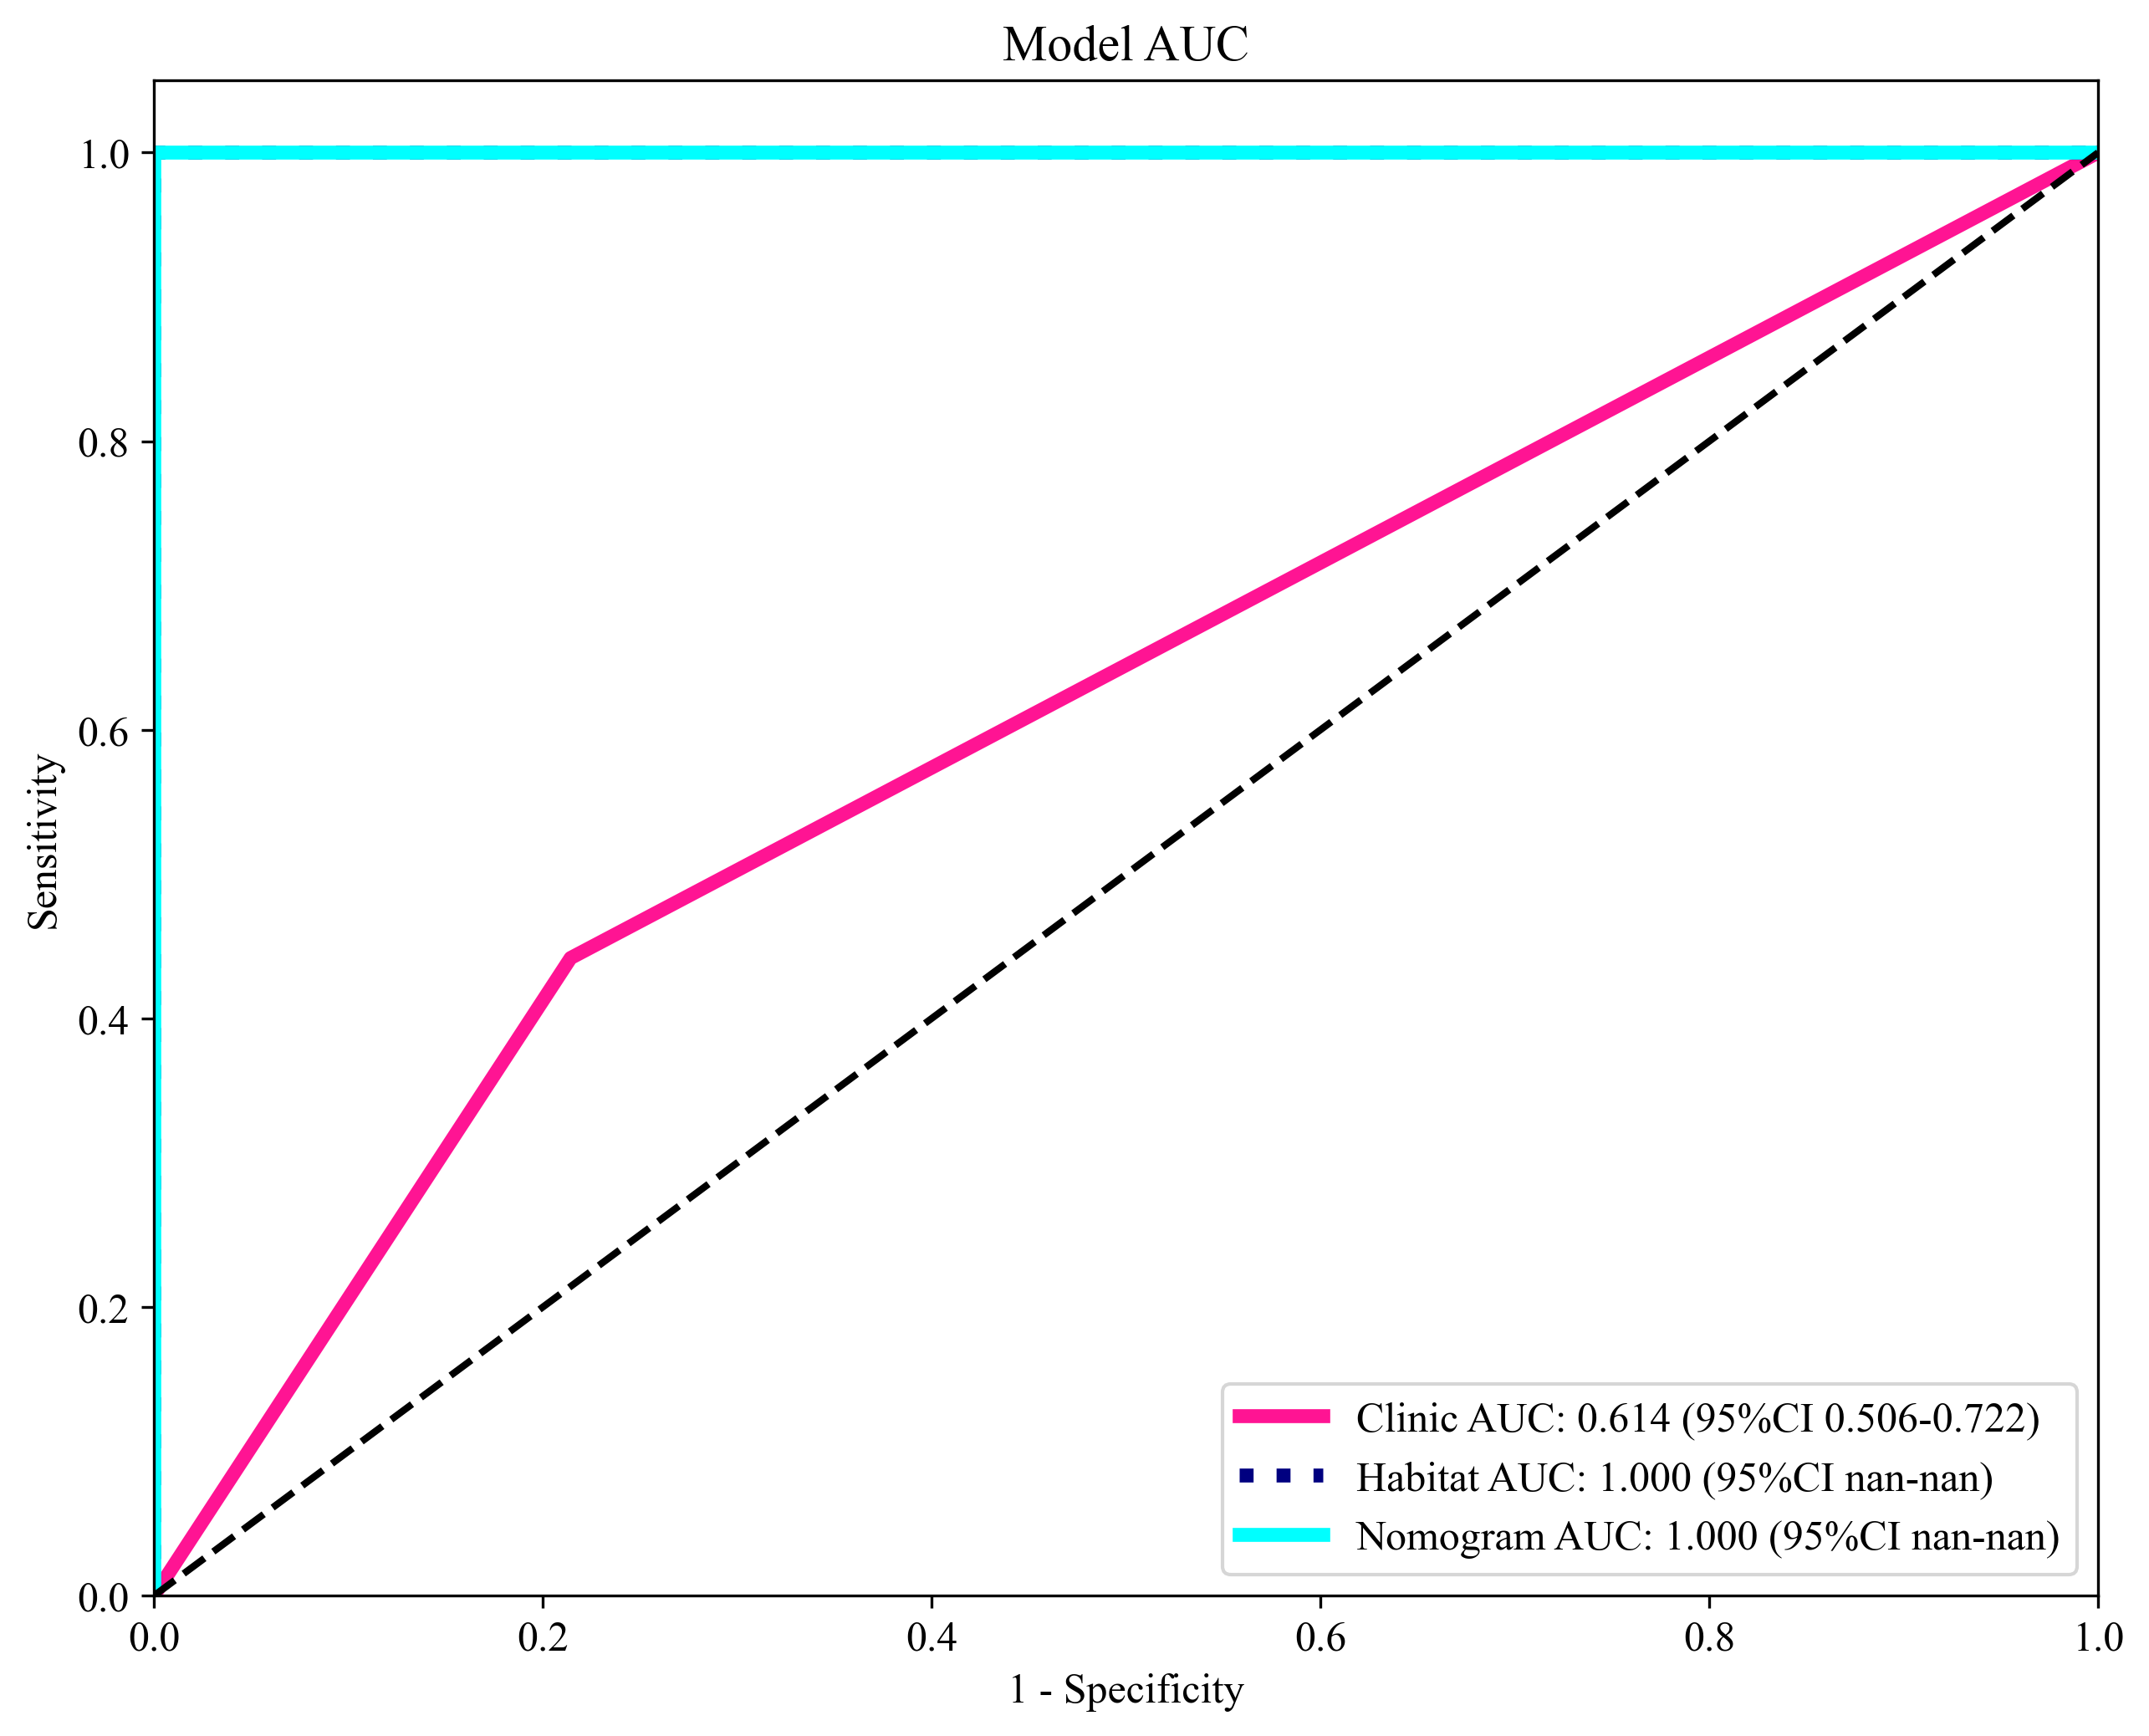

In [4]:
pred_column = [f'{task}-0', f'{task}-1']
results.columns = ['ID', '-0', 'Nomogram']
ALL_results = pd.merge(ALL_results, results, on='ID', how='inner')
gt = [np.array(ALL_results[task]) for d in model_names]
pred_train = [np.array(ALL_results[d]) for d in model_names]
okcomp.comp1.draw_roc(gt, pred_train, labels=model_names, title=f"Model AUC")
plt.savefig(f'img/{subset}_auc.svg')

In [5]:
from onekey_algo.custom.components.metrics import analysis_pred_binary
metric = []
for mname, y, score in zip(model_names, gt, pred_train):
    # compute validation set metrics
    acc, auc, ci, tpr, tnr, ppv, npv, precision, recall, f1, thres = analysis_pred_binary(y, score)
    ci = f"{ci[0]:.4f} - {ci[1]:.4f}"
    metric.append((mname, acc, auc, ci, tpr, tnr, ppv, npv, precision, recall, f1, thres, f"Train"))
pd.DataFrame(metric, index=None, columns=['Signature', 'Accuracy', 'AUC', '95% CI', 'Sensitivity', 'Specificity', 
                                          'PPV', 'NPV', 'Precision', 'Recall', 'F1','Threshold', 'Cohort'])

,Signature,Accuracy,AUC,95% CI,Sensitivity,Specificity,PPV,NPV,Precision,Recall,F1,Threshold,Cohort
0,Clinic,0.577,0.614,0.5060 - 0.7216,0.442,0.786,0.76,0.478,0.76,0.442,0.559,0.745,Train
1,Habitat,1.000,1.000,1.0000 - 1.0000,1.000,1.000,1.00,1.000,1.00,1.000,1.000,0.634,Train
2,Nomogram,1.000,1.000,1.0000 - 1.0000,1.000,1.000,1.00,1.000,1.00,1.000,1.000,0.642,Train


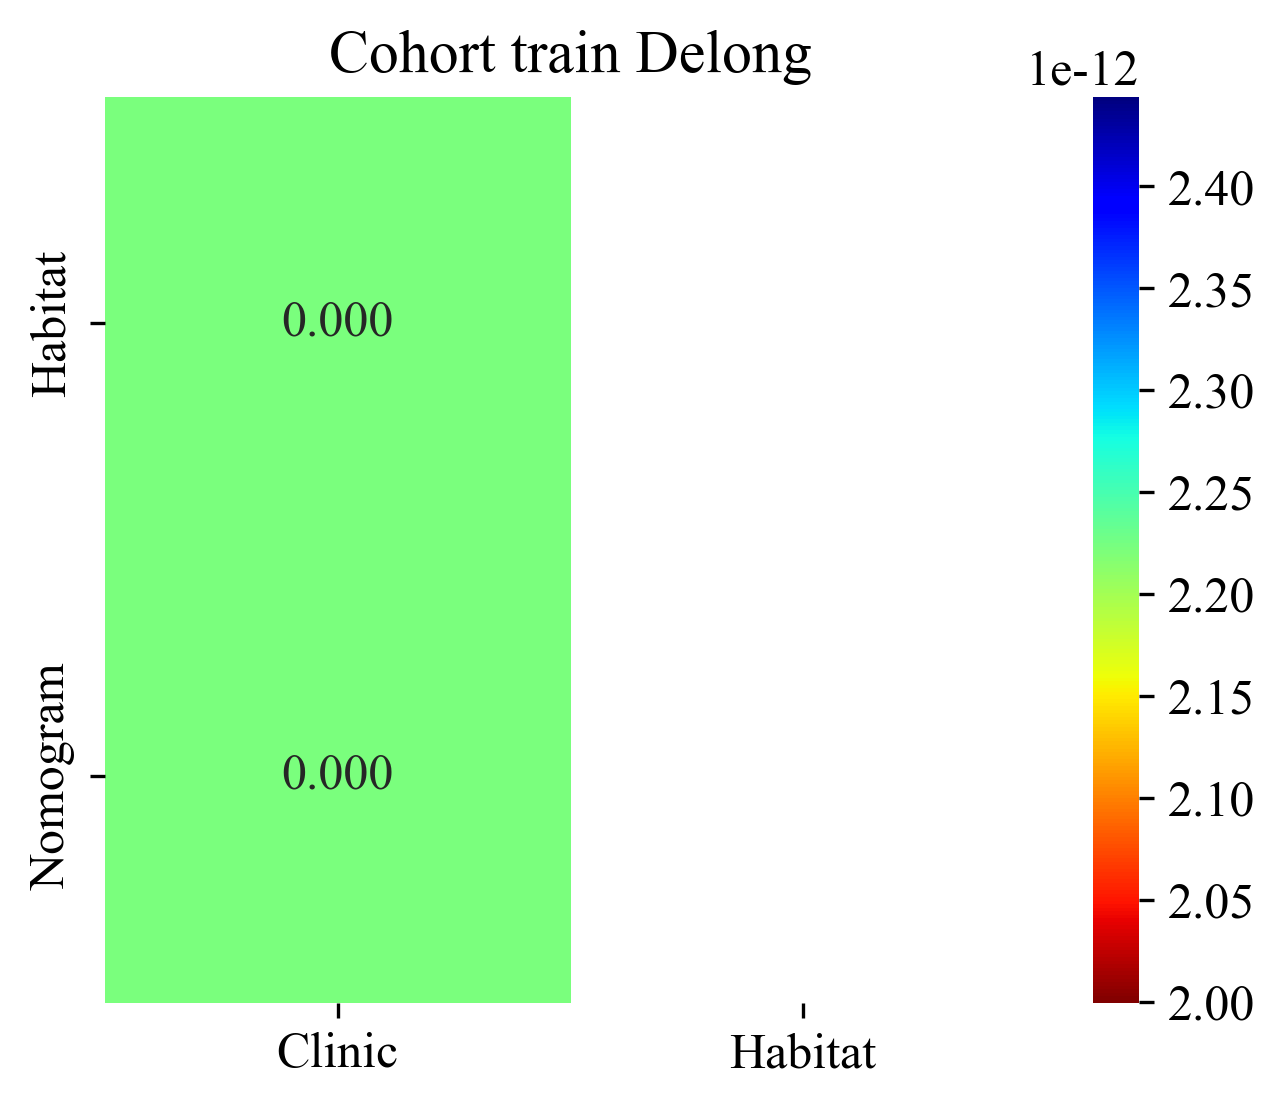

In [6]:
# =====================================================================# WARNING: LEGACY v2 CODE -- DO NOT USE FOR v4 NUMBERS# =====================================================================# This cell uses onekey_algo.custom.components.delong.delong_roc_test,# which is the v2 DeLong implementation (onekey_algo platform). The v4# manuscript reports p-values from the Sun & Xu (2014) analytic DeLong# implementation in Cell 20 of this notebook -- not from this cell.## v2 numbers (this cell, onekey_algo DeLong):#     Habitat vs. Clinic      p = 0.137#     Nomogram vs. Clinic     p = 0.064#     Habitat vs. Nomogram    p = 0.917## v4 numbers (Cell 20/21, Sun & Xu 2014 analytic DeLong):#     Habitat vs. Clinic      p < 0.0001  (Z = +5.89)#     Nomogram vs. Clinic     p < 0.0001  (Z = +5.68)#     Habitat vs. Nomogram    p = 0.877    (Z = -0.155)## This cell is RETAINED FOR TRANSPARENCY / COMPARISON ONLY. The# reviewer should use the Cell 20/21 Sun & Xu analytic results to# verify the manuscript's reported p-values.# =====================================================================from onekey_algo.custom.components.delong import delong_roc_testfrom onekey_algo.custom.components.comp1 import draw_matrixdelong = []delong_columns = []this_delong = []plt.figure(figsize=(5, 4))cm = np.zeros((len(model_names), len(model_names)))for i, mni in enumerate(model_names):    for j, mnj in enumerate(model_names):        if i <= j:            cm[i][j] = np.nan        else:            cm[i][j] = delong_roc_test(ALL_results[task], ALL_results[mni], ALL_results[mnj])[0][0]cm = pd.DataFrame(cm[1:, :-1], index=model_names[1:], columns=model_names[:-1])draw_matrix(cm, annot=True, cmap='jet_r', cbar=True)plt.title(f'Cohort {subset} Delong')plt.savefig(f'img/delong_each_cohort_{subset}.svg', bbox_inches = 'tight')plt.show()

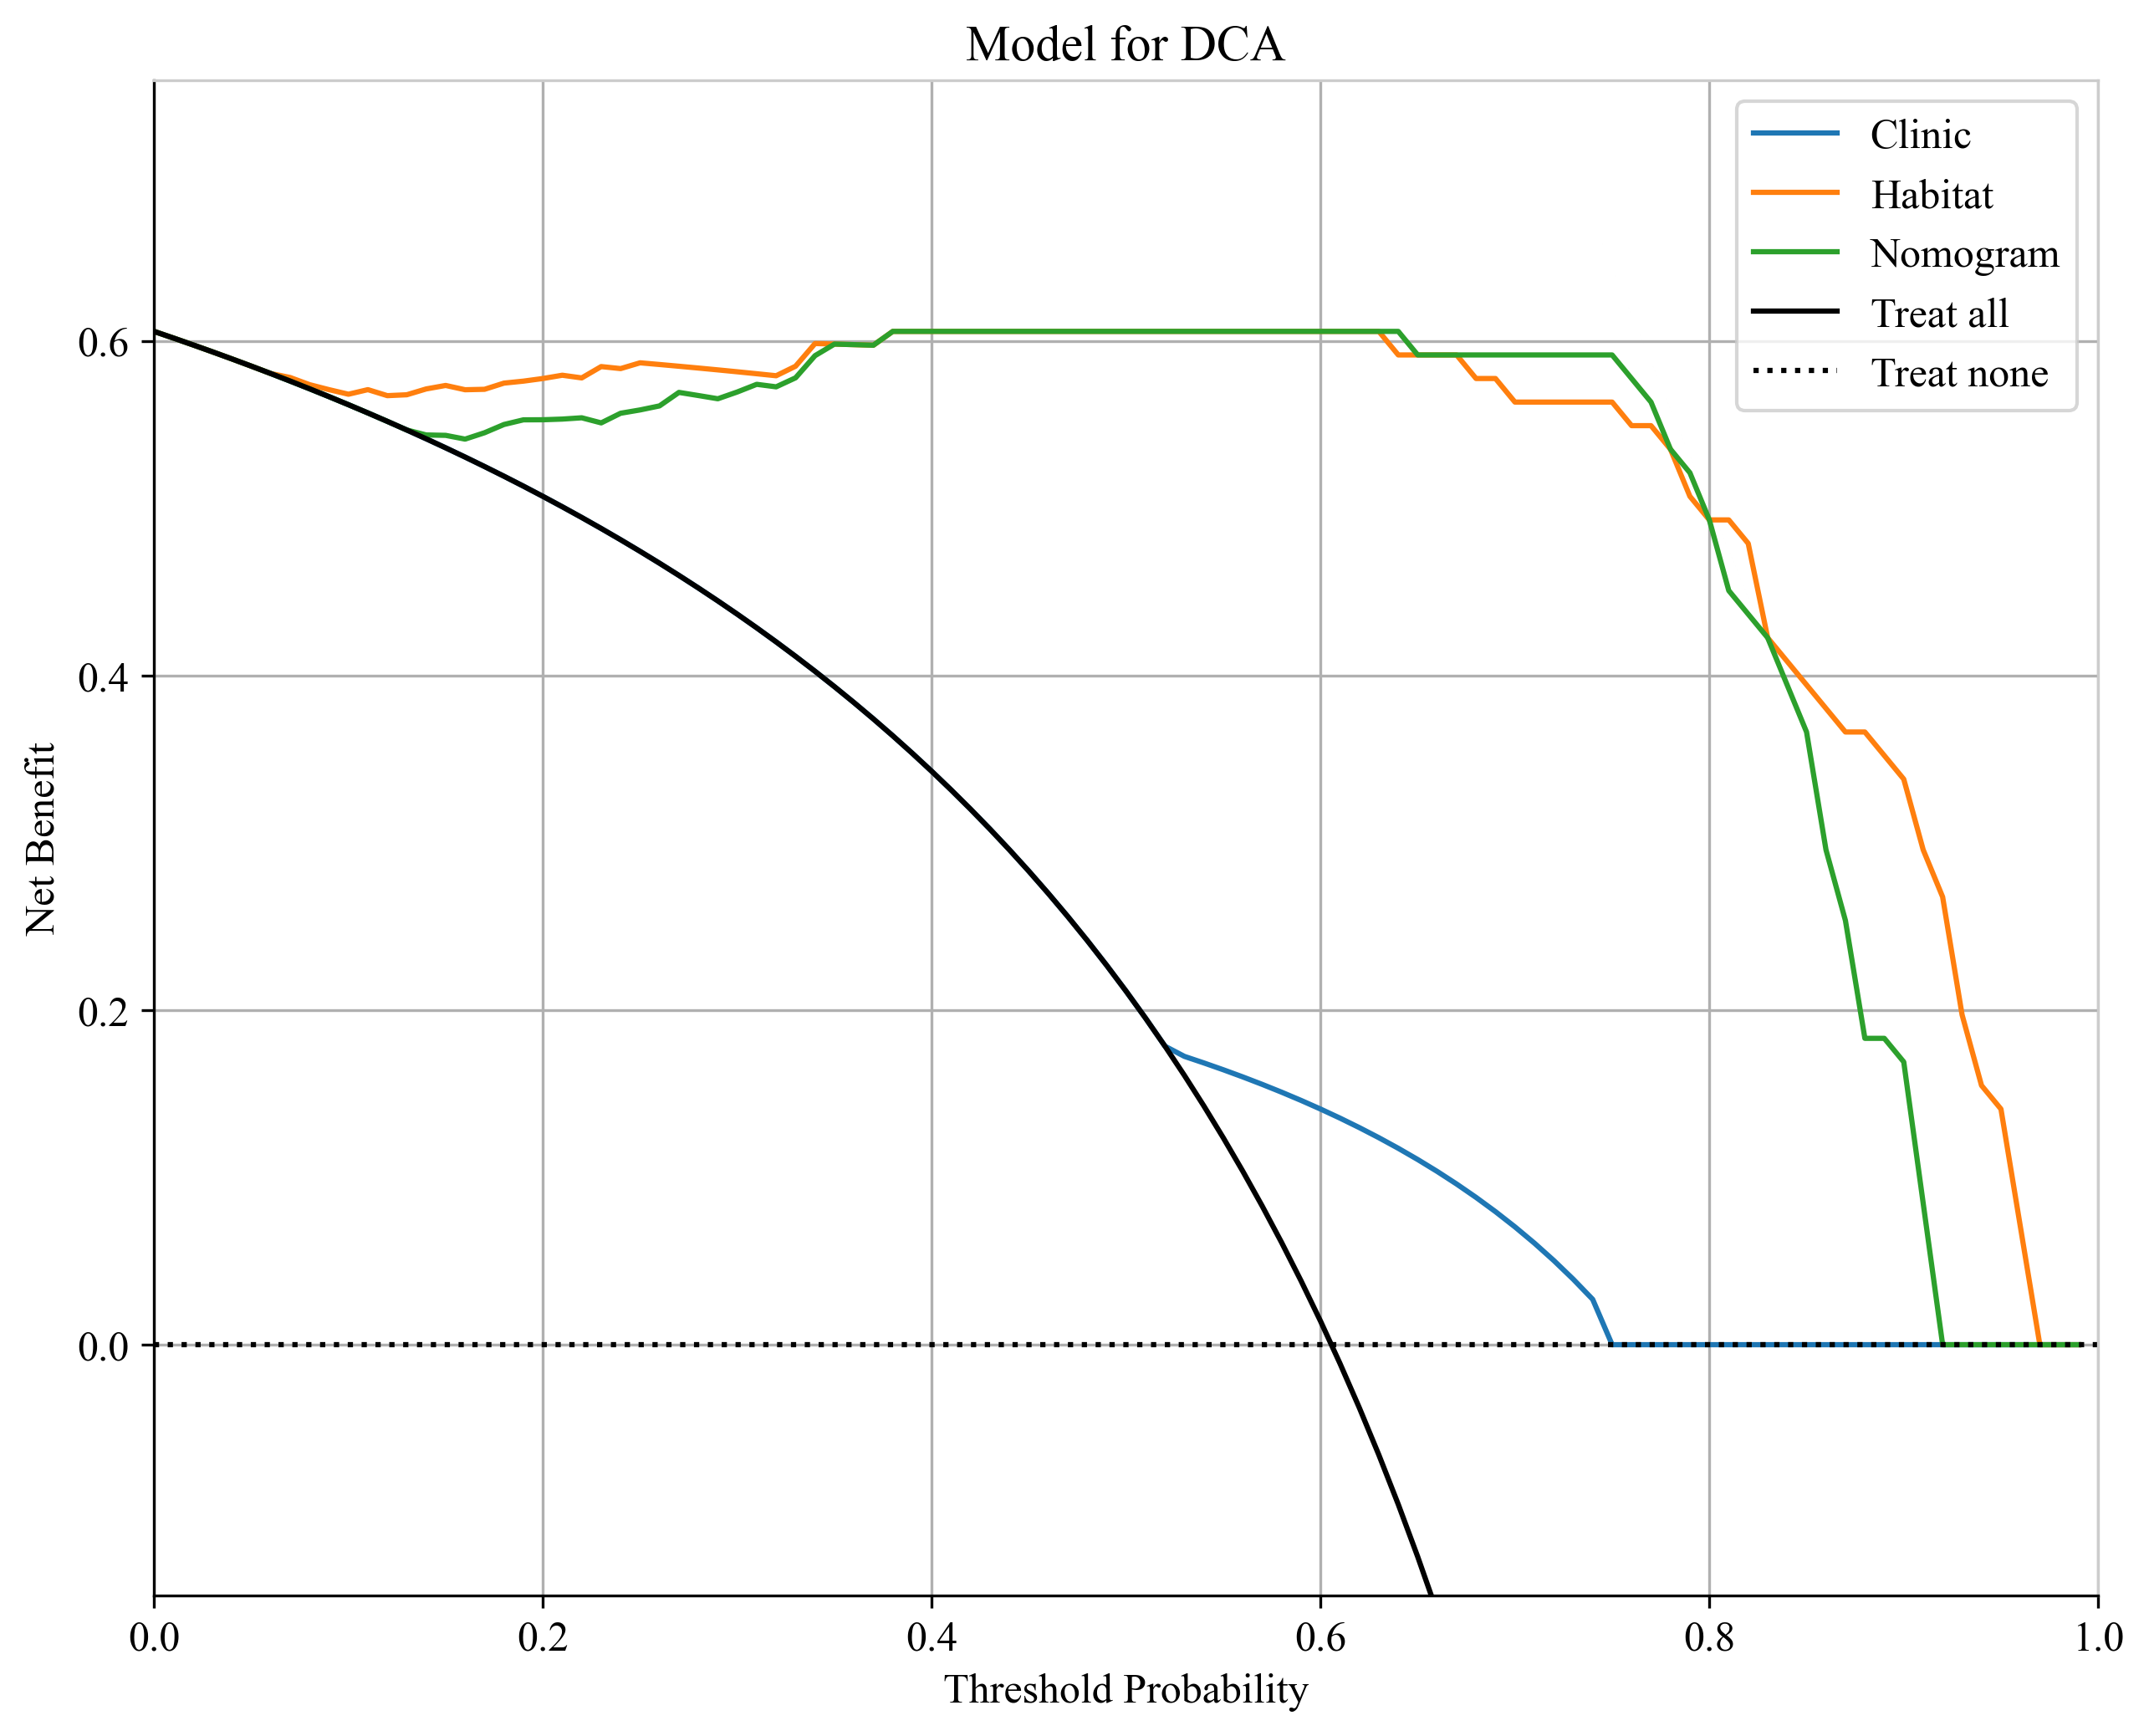

In [7]:
from onekey_algo.custom.components.comp1 import plot_DCA
plot_DCA([ALL_results[mn] for mn in model_names], ALL_results[task], title=f'Model for DCA', labels=model_names)
plt.savefig(f'img/{subset}_dca.svg')

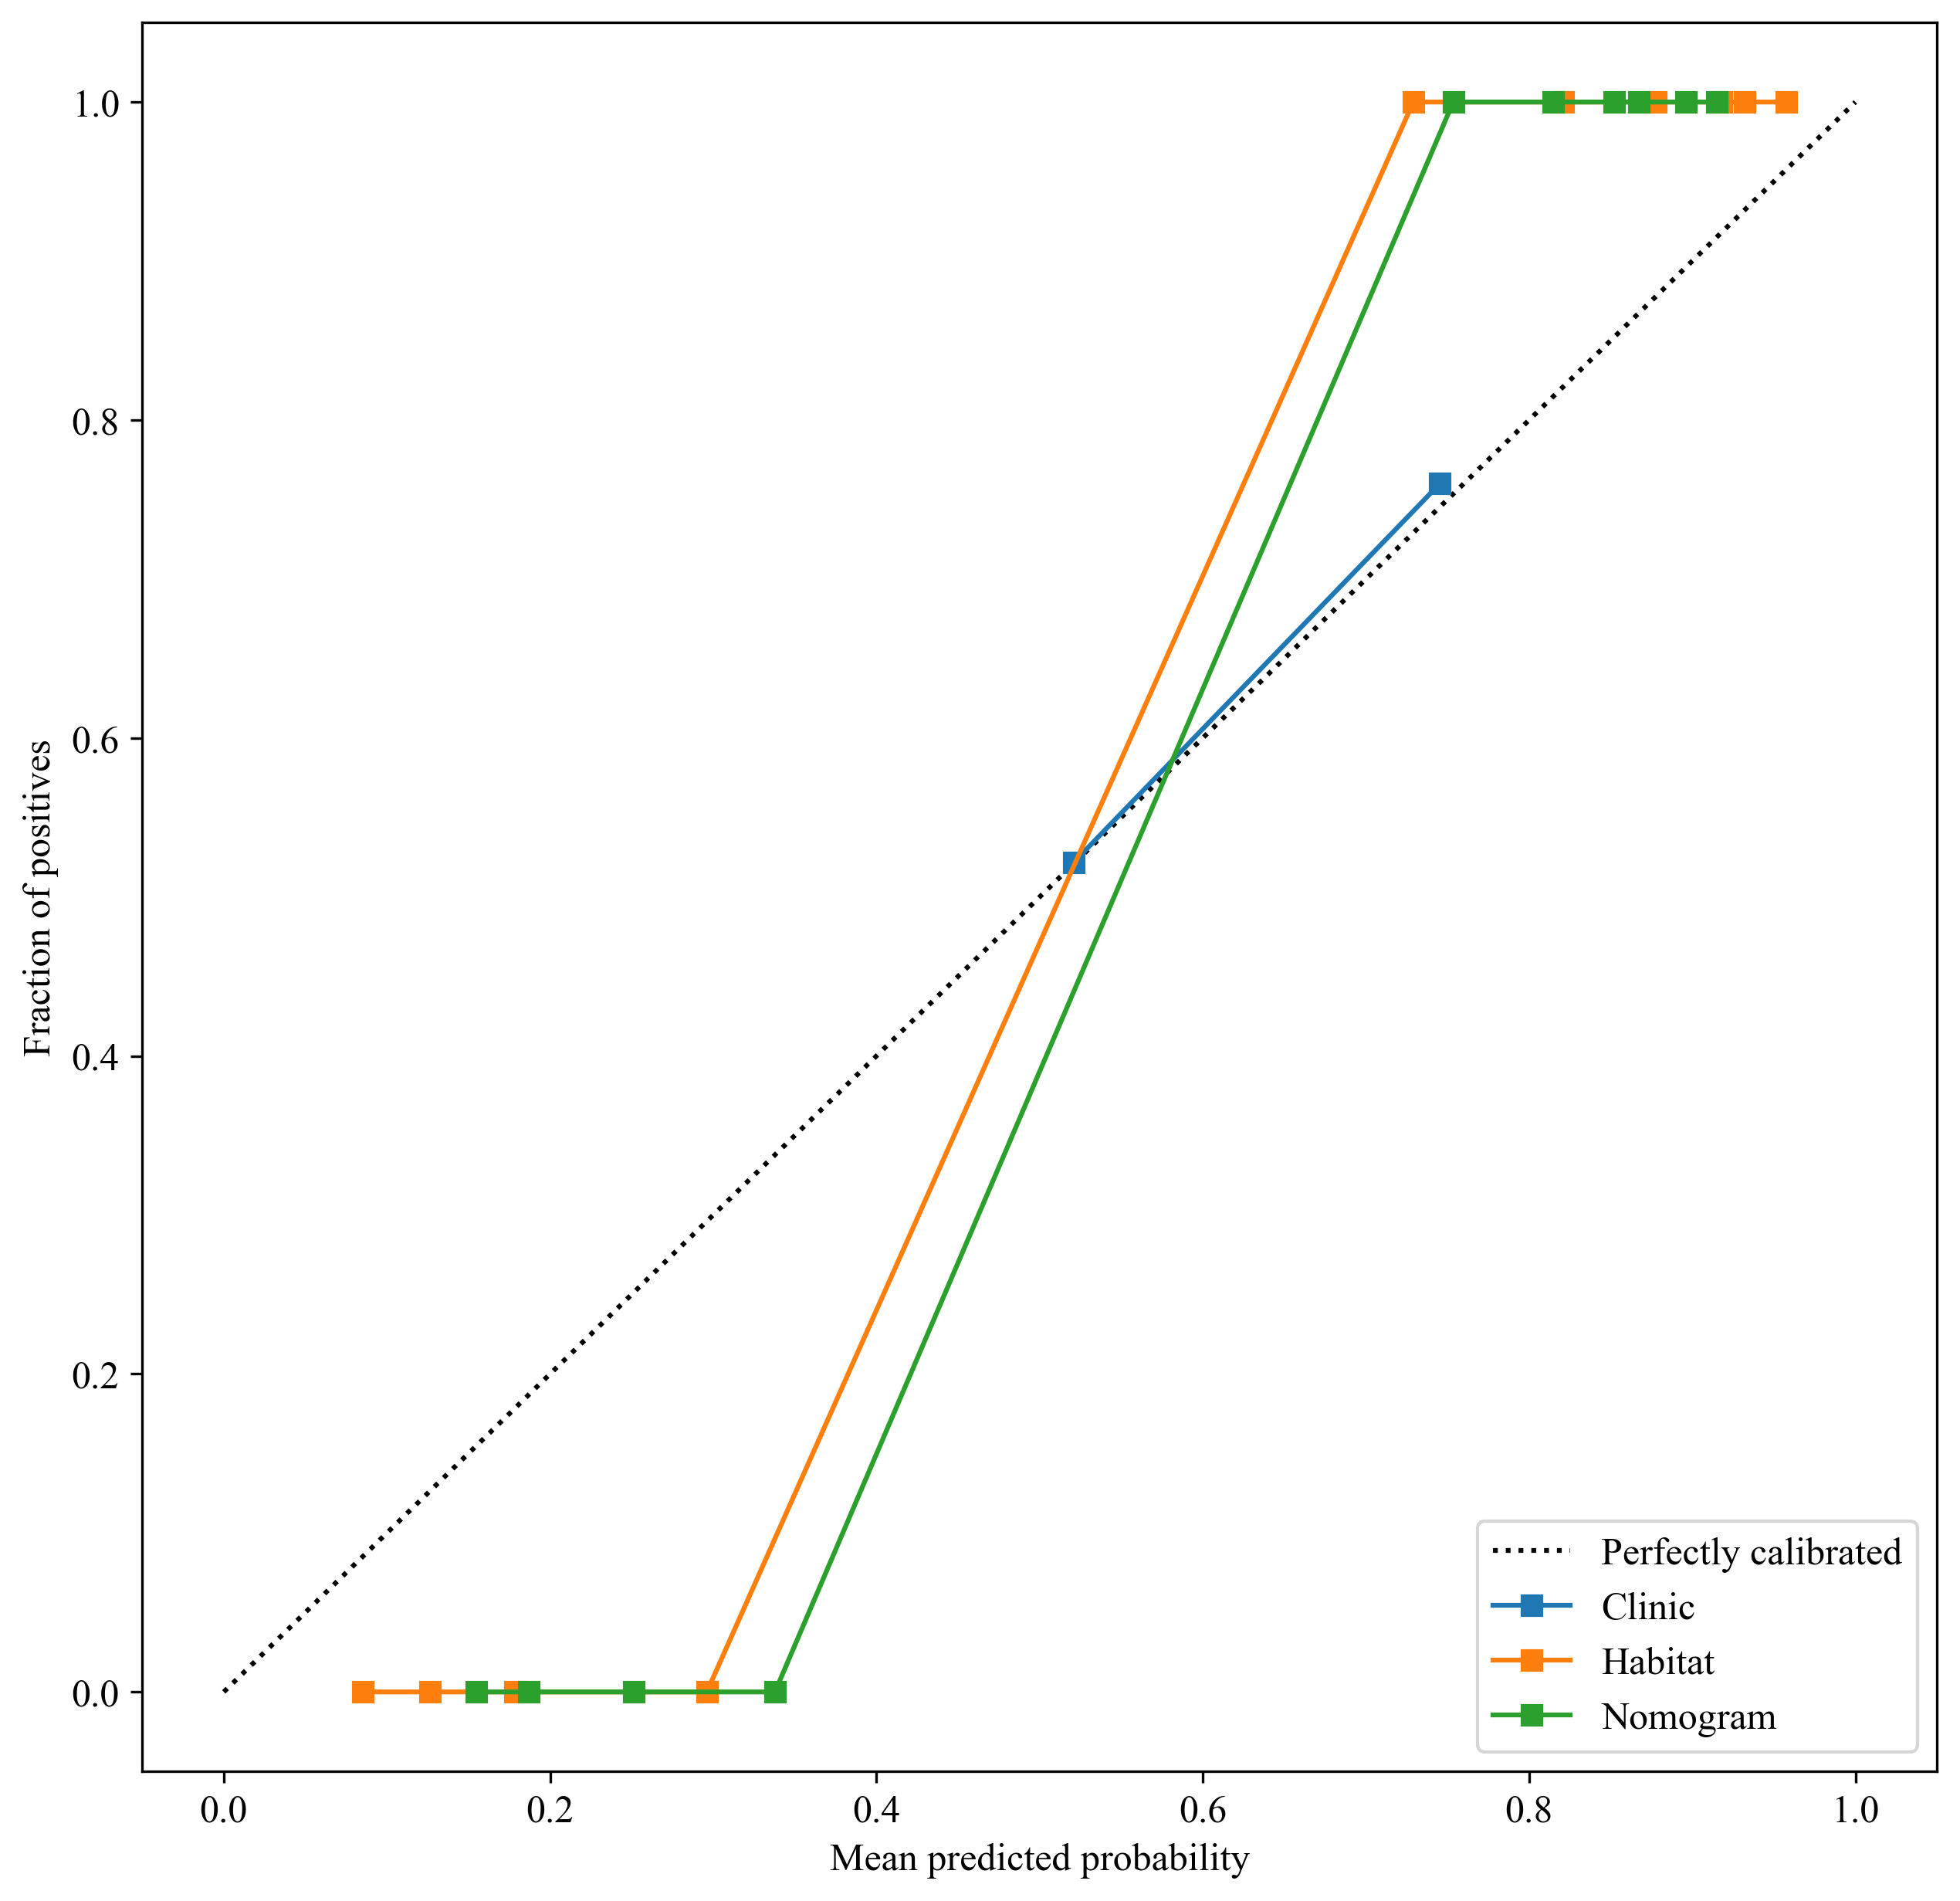

In [8]:
from onekey_algo.custom.components.comp1 import draw_calibration
draw_calibration(pred_scores=pred_train, n_bins=10, y_test=gt, model_names=model_names)
plt.savefig(f'img/{subset}_cali.svg')

In [9]:
from onekey_algo.custom.components import stats

hosmer = []
hosmer.append([stats.hosmer_lemeshow_test(y_true, y_pred, bins=15) 
              for fn, y_true, y_pred in zip(model_names, gt, pred_train)])
pd.DataFrame(hosmer, columns=model_names)

,Clinic,Habitat,Nomogram
0,1.0,0.612,0.33


[2026-07-15 20:06:44 - situation.py:  45]	INFO	cffi mode is CFFI_MODE.ANY
[2026-07-15 20:06:44 - situation.py: 189]	INFO	R home found: K:\onekeyAI\OnekeyPlatform\onekey_envs\Lib\R
[2026-07-15 20:06:45 - situation.py: 136]	ERROR	Unable to determine R library path: Command '('K:\\onekeyAI\\OnekeyPlatform\\onekey_envs\\Lib\\R\\bin\\Rscript', '-e', 'cat(Sys.getenv("LD_LIBRARY_PATH"))')' returned non-zero exit status 1.
[2026-07-15 20:06:45 - situation.py: 147]	INFO	LD_LIBRARY_PATH: 
[2026-07-15 20:06:45 - embedded.py:  20]	INFO	Default options to initialize R: rpy2, --quiet, --no-save


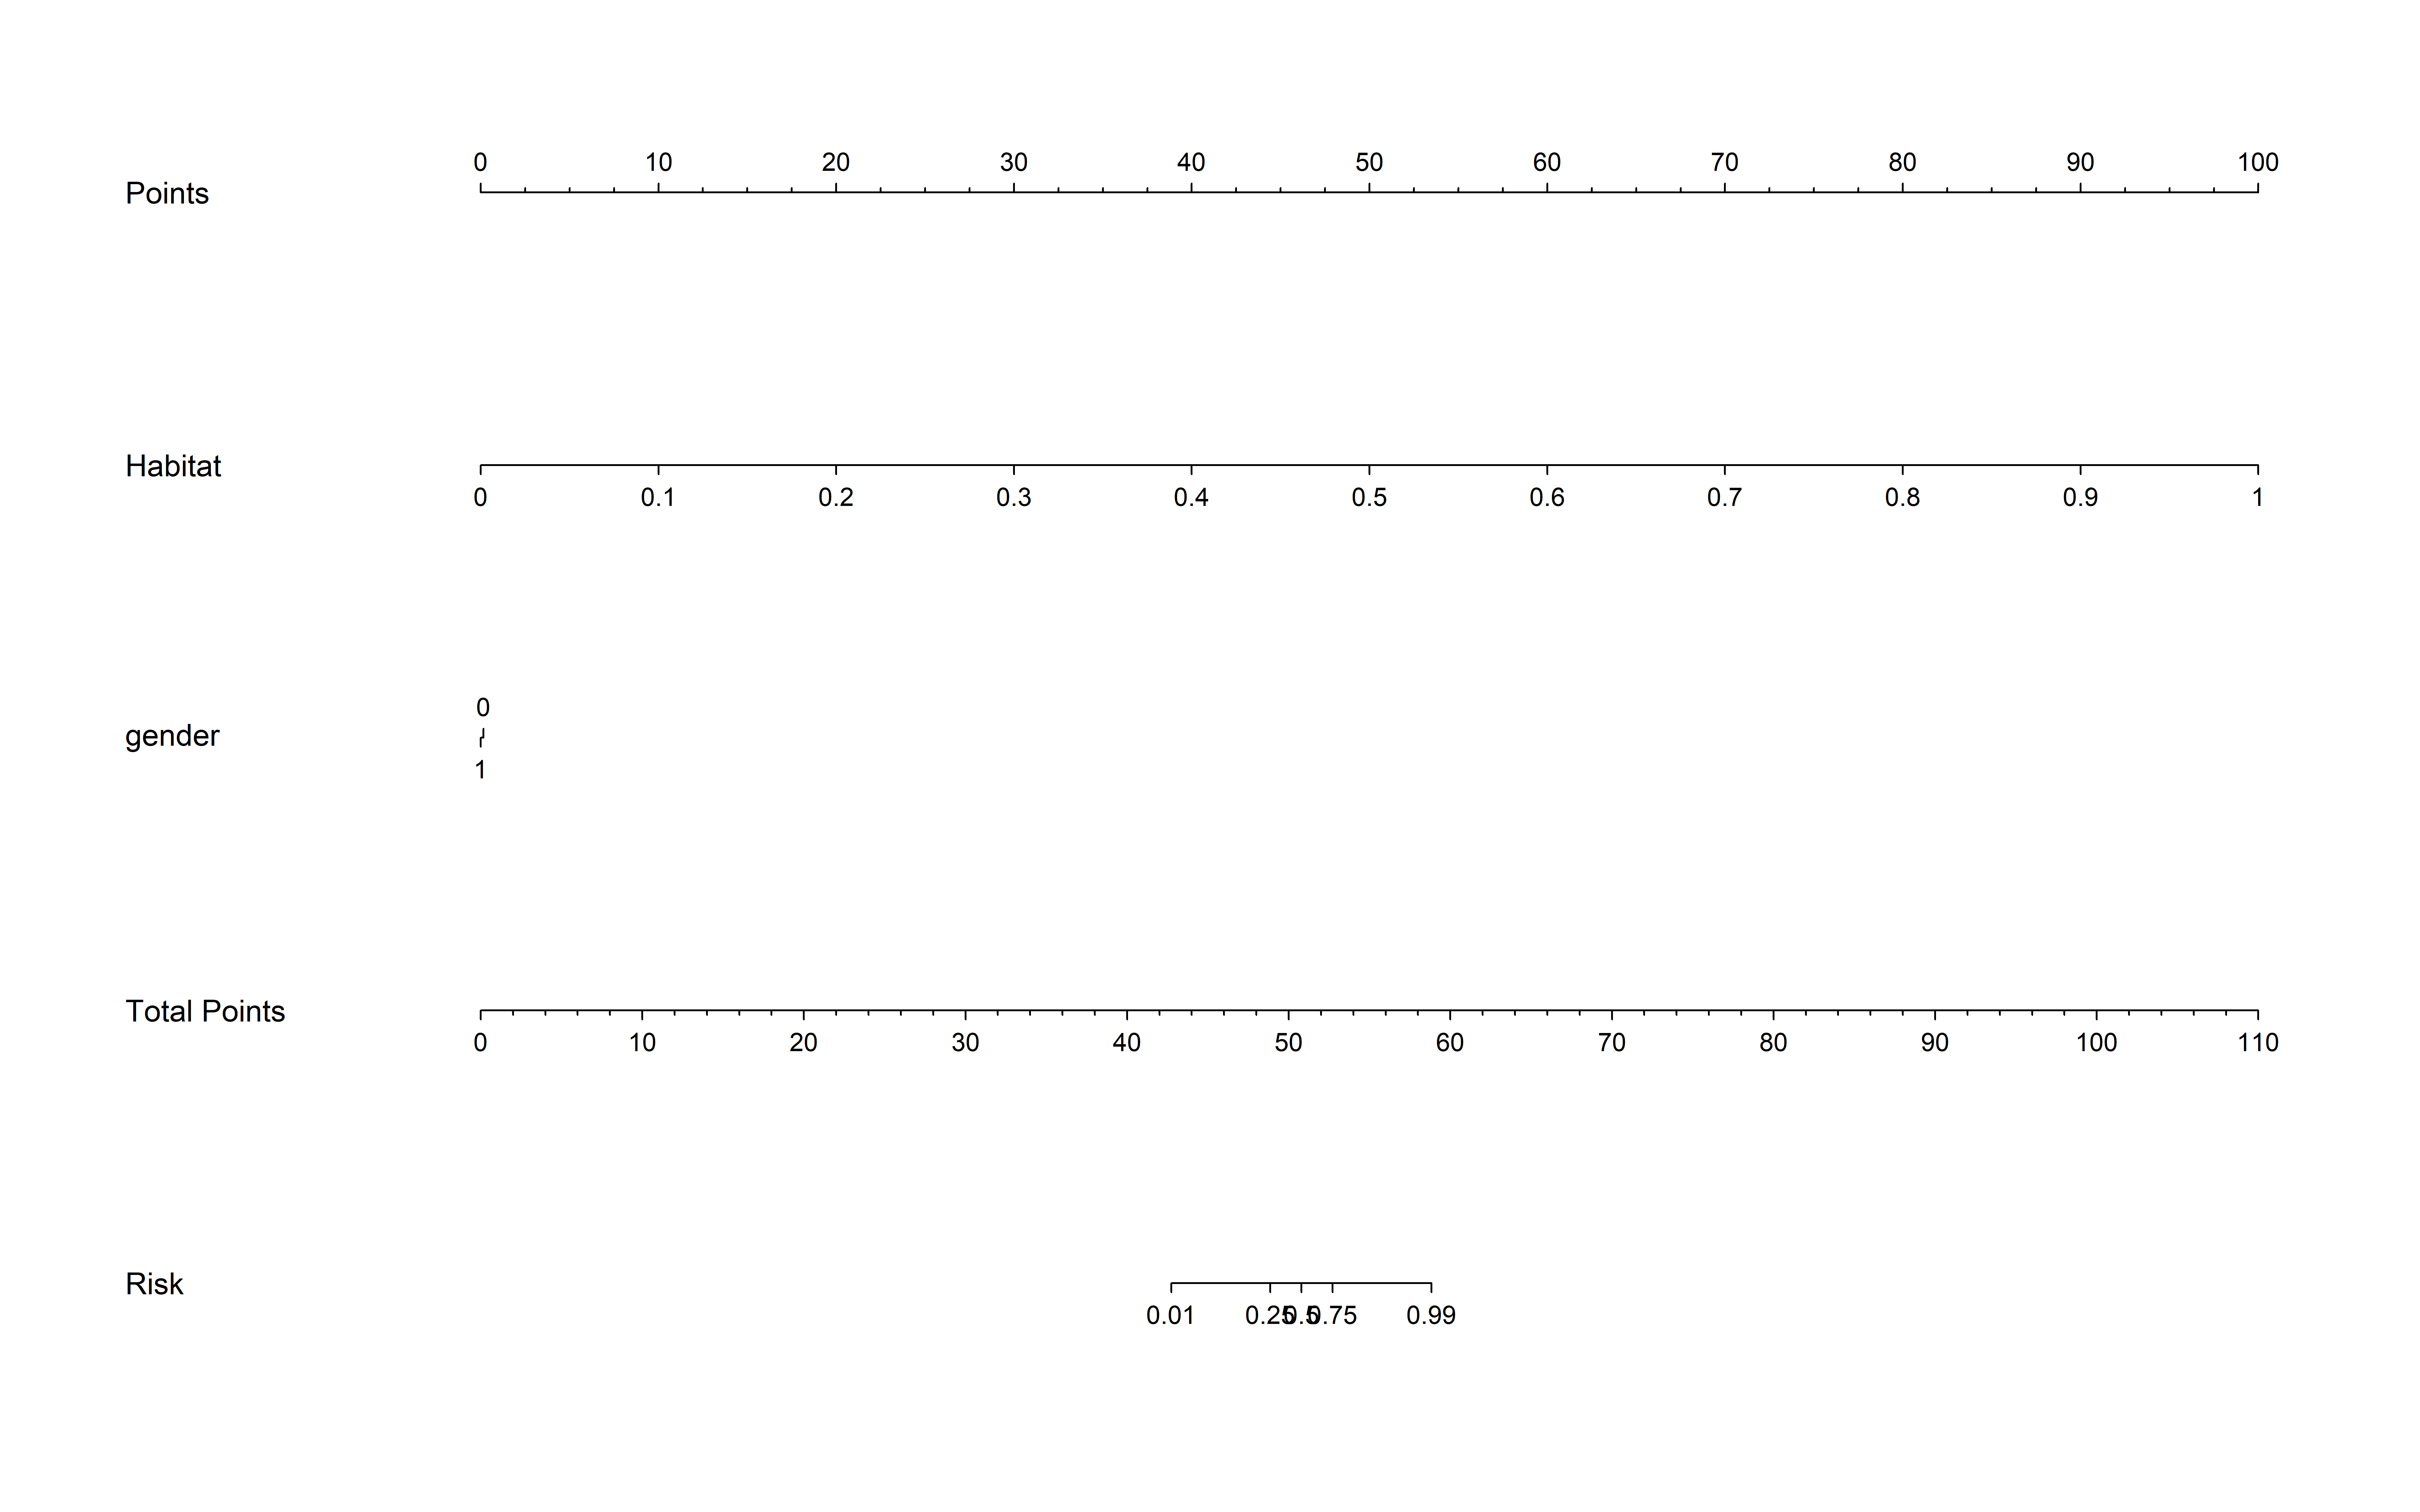

In [10]:
from onekey_algo.custom.components import nomogram
import shutil

nomogram.risk_nomogram(ALL_results, result=task, columns=model_names[1:-1] + list(Clinic.columns[1:]), width=8000, height=5000,
                       x_range='0.01,0.25,0.5,0.75,0.99')

# Test set-Nomogram

In [11]:
import pandas as pd

subset = 'test'
ALL_results = None
for mn in model_names[:-1]:
    r = pd.read_csv(f'./results/{mn}_{bst_model}_{subset}.csv')
    r.columns = ['ID', '-0', mn]
    if ALL_results is None:
        ALL_results = r
    else:
        ALL_results = pd.merge(ALL_results, r, on='ID', how='inner')

ALL_results = pd.merge(ALL_results, label_data, on='ID', how='inner')

Clinic = pd.read_csv('clinic_sel.csv')
Clinic = Clinic[[c for c in Clinic.columns if c not in [task, group_info]]]
ALL_results = pd.merge(ALL_results, Clinic, on='ID', how='inner')

ALL_results = ALL_results.dropna(axis=1)
ALL_results

,ID,-0_x,Clinic,-0_y,Habitat,label,gender
0,5.nii.gz,0.479,0.521,0.120,0.880,1,0
1,6.nii.gz,0.479,0.521,0.570,0.430,1,0
2,7.nii.gz,0.479,0.521,0.184,0.816,1,0
3,9.nii.gz,0.255,0.745,0.166,0.834,1,1
4,10.nii.gz,0.255,0.745,0.132,0.868,1,1
5,13.nii.gz,0.255,0.745,0.404,0.596,1,1
6,14.nii.gz,0.479,0.521,0.511,0.489,1,0
7,16.nii.gz,0.479,0.521,0.298,0.702,1,0
8,18.nii.gz,0.479,0.521,0.201,0.799,1,0
9,24.nii.gz,0.255,0.745,0.195,0.805,1,1


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from onekey_algo.custom.components import metrics

# model = LogisticRegression(random_state=0)
# model = SVC(probability=True, random_state=0)
data_x = ALL_results[model_names[1:-1] + list(Clinic.columns[1:])]
data_y = ALL_results[task]
# model.fit(data_x, data_y)
results = model.predict_proba(data_x)
results = pd.DataFrame(results, index=ALL_results['ID'], columns=[f'{task}-0', f'{task}-1']).reset_index()
results.to_csv(f'./results/Nomo_{subset}.csv', index=False, header=True)
pd.DataFrame([metrics.analysis_pred_binary(ALL_results[task], results[f'{task}-1'])], 
                  columns=['acc', 'auc', '95%CI', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'Precision', 'Recall', 'F1', 'Threshold'])

,acc,auc,95%CI,Sensitivity,Specificity,PPV,NPV,Precision,Recall,F1,Threshold
0,0.833,0.872,"[0.77267, 0.972085]",0.731,0.955,0.95,0.75,0.95,0.731,0.826,0.705


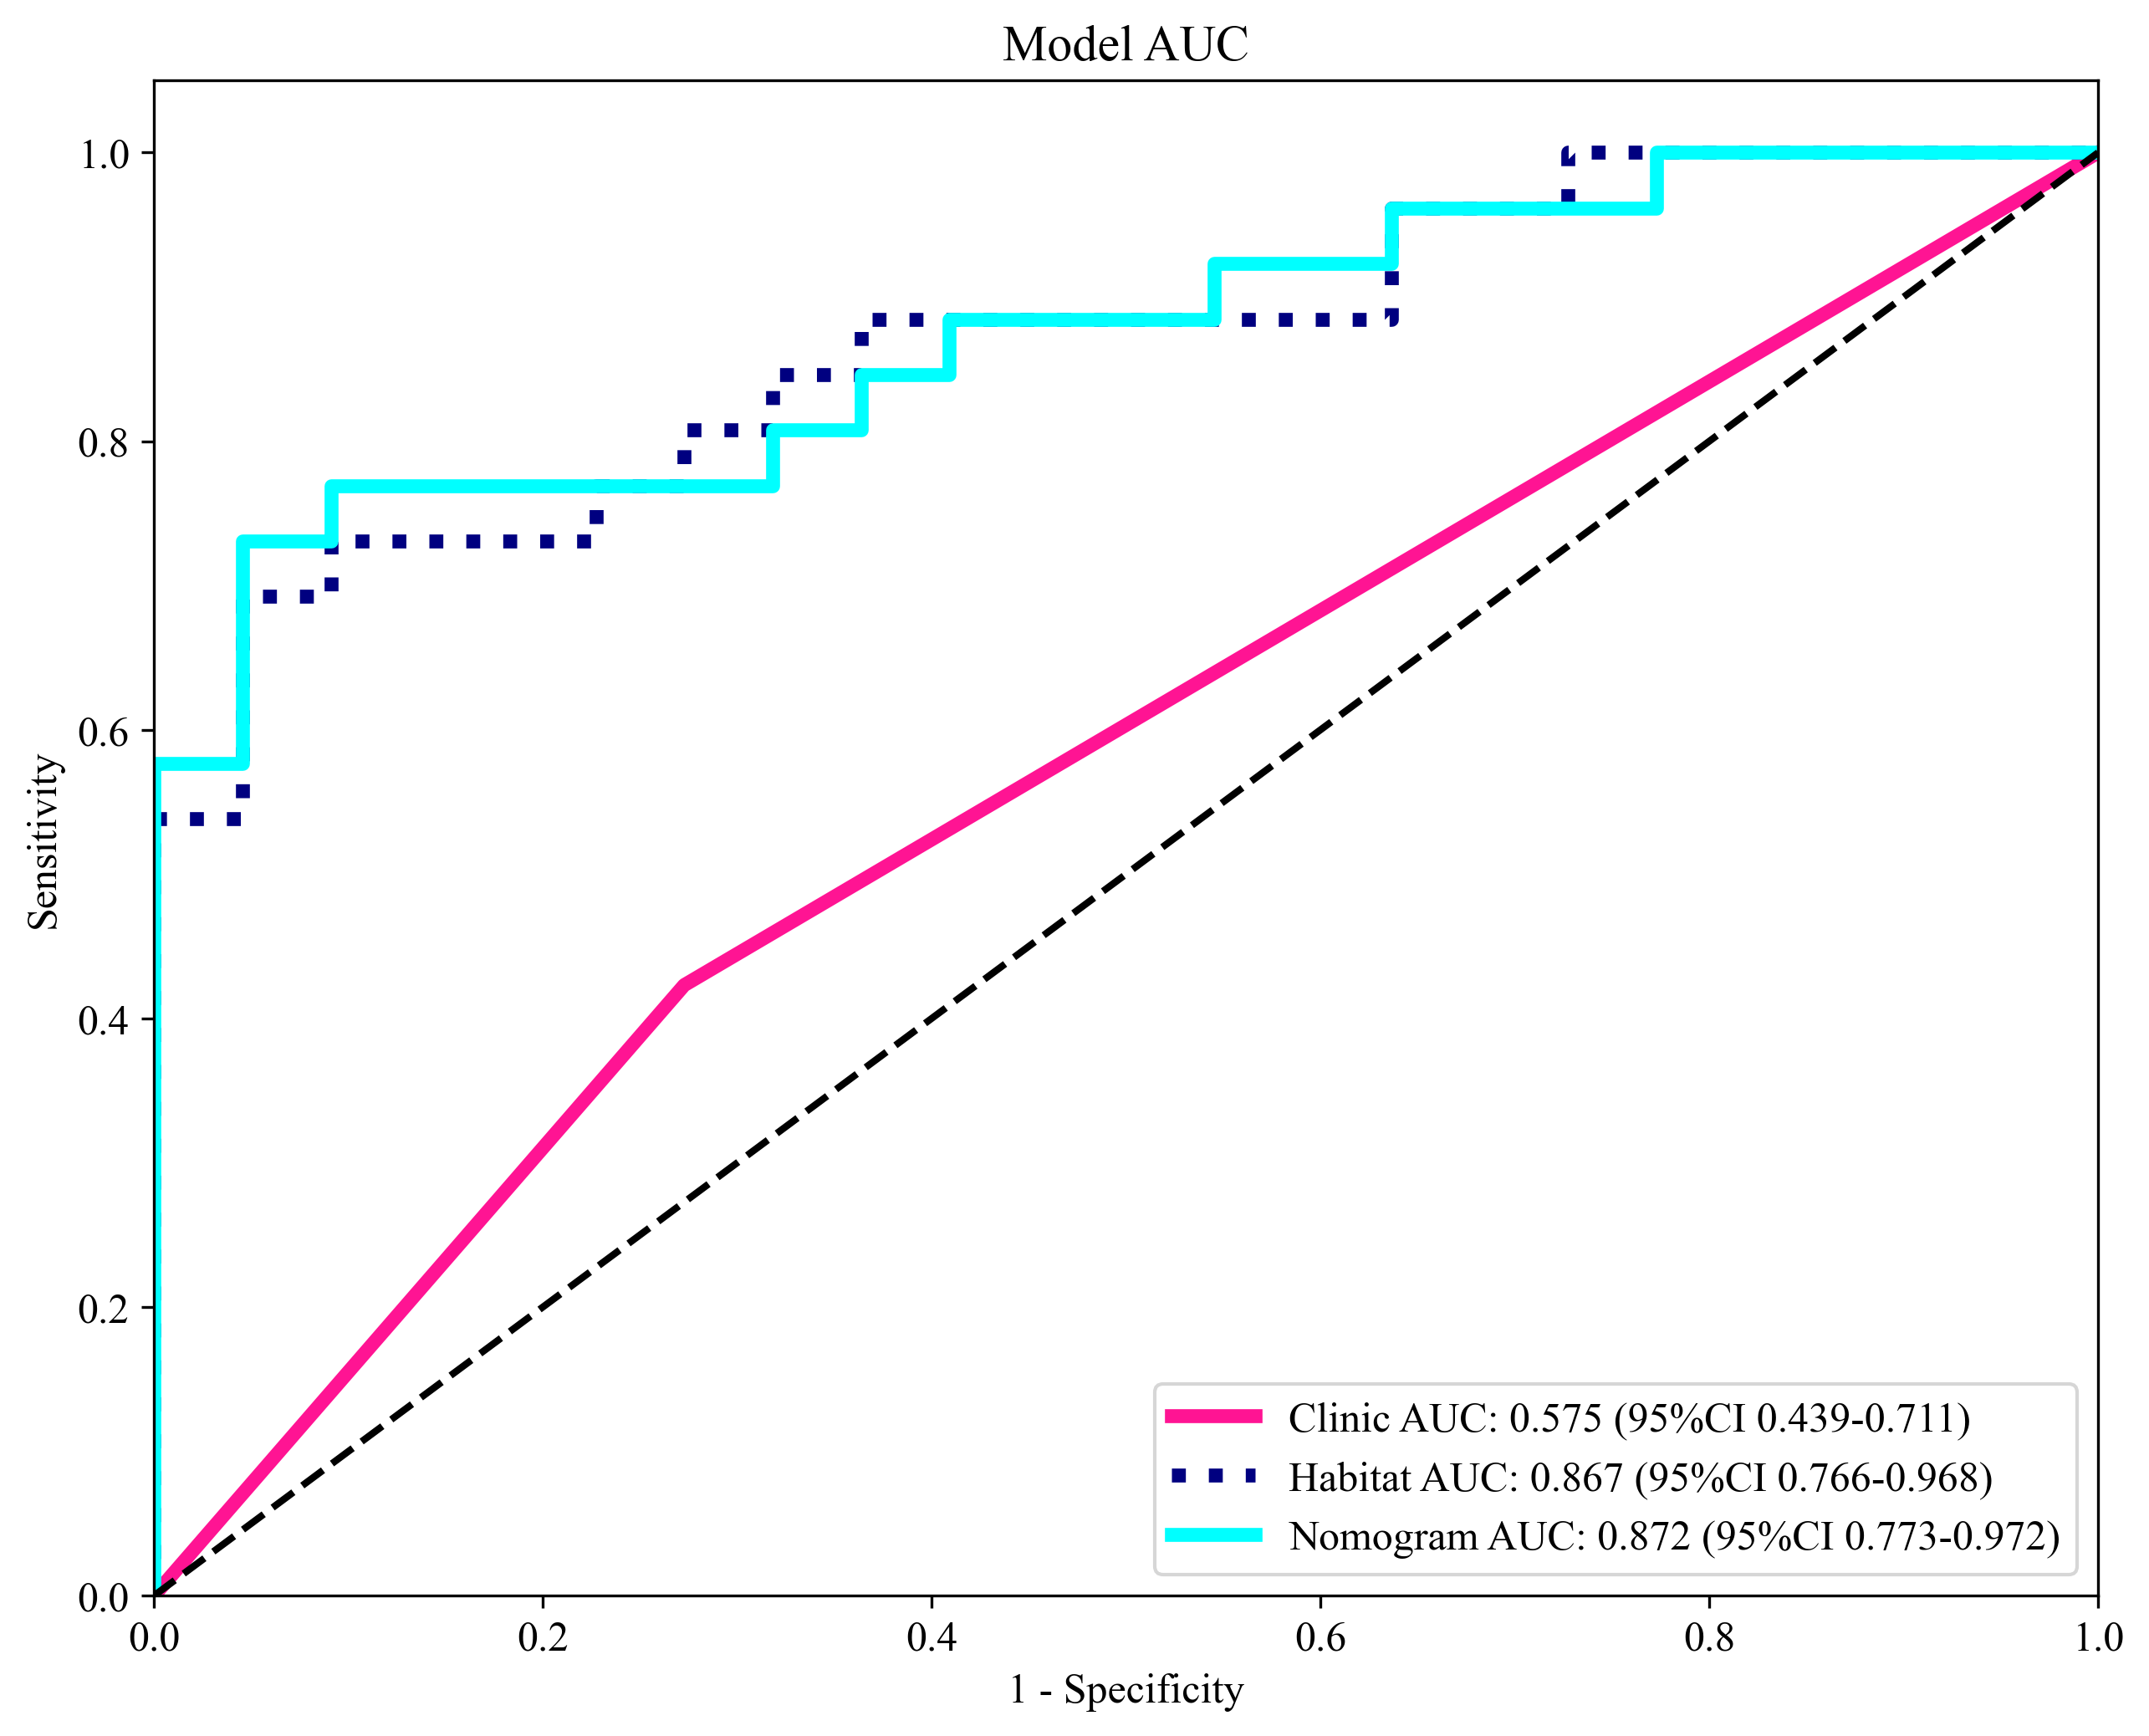

In [13]:
pred_column = [f'{task}-0', f'{task}-1']
results.columns = ['ID', '-0', 'Nomogram']
ALL_results = pd.merge(ALL_results, results, on='ID', how='inner')
gt = [np.array(ALL_results[task]) for d in model_names]
pred_train = [np.array(ALL_results[d]) for d in model_names]
okcomp.comp1.draw_roc(gt, pred_train, labels=model_names, title=f"Model AUC")
plt.savefig(f'img/{subset}_auc.svg')

In [14]:
from onekey_algo.custom.components.metrics import analysis_pred_binary
for mname, y, score in zip(model_names, gt, pred_train):
    # compute validation set metrics
    acc, auc, ci, tpr, tnr, ppv, npv, precision, recall, f1, thres = analysis_pred_binary(y, score)
    ci = f"{ci[0]:.4f} - {ci[1]:.4f}"
    metric.append((mname, acc, auc, ci, tpr, tnr, ppv, npv, precision, recall, f1, thres, f"Test"))
metric = pd.DataFrame(metric, index=None, columns=['Signature', 'Accuracy', 'AUC', '95% CI',
                                                   'Sensitivity', 'Specificity', 
                                                   'PPV', 'NPV', 'Precision', 'Recall', 'F1',
                                                   'Threshold', 'Cohort'])

metric

,Signature,Accuracy,AUC,95% CI,Sensitivity,Specificity,PPV,NPV,Precision,Recall,F1,Threshold,Cohort
0,Clinic,0.577,0.614,0.5060 - 0.7216,0.442,0.786,0.760,0.478,0.760,0.442,0.559,0.745,Train
1,Habitat,1.000,1.000,1.0000 - 1.0000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.634,Train
2,Nomogram,1.000,1.000,1.0000 - 1.0000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.642,Train
3,Clinic,0.562,0.575,0.4394 - 0.7110,0.423,0.727,0.647,0.516,0.647,0.423,0.512,0.745,Test
4,Habitat,0.812,0.867,0.7662 - 0.9681,0.692,0.955,0.947,0.724,0.947,0.692,0.800,0.702,Test
5,Nomogram,0.833,0.872,0.7727 - 0.9721,0.731,0.955,0.950,0.750,0.950,0.731,0.826,0.705,Test


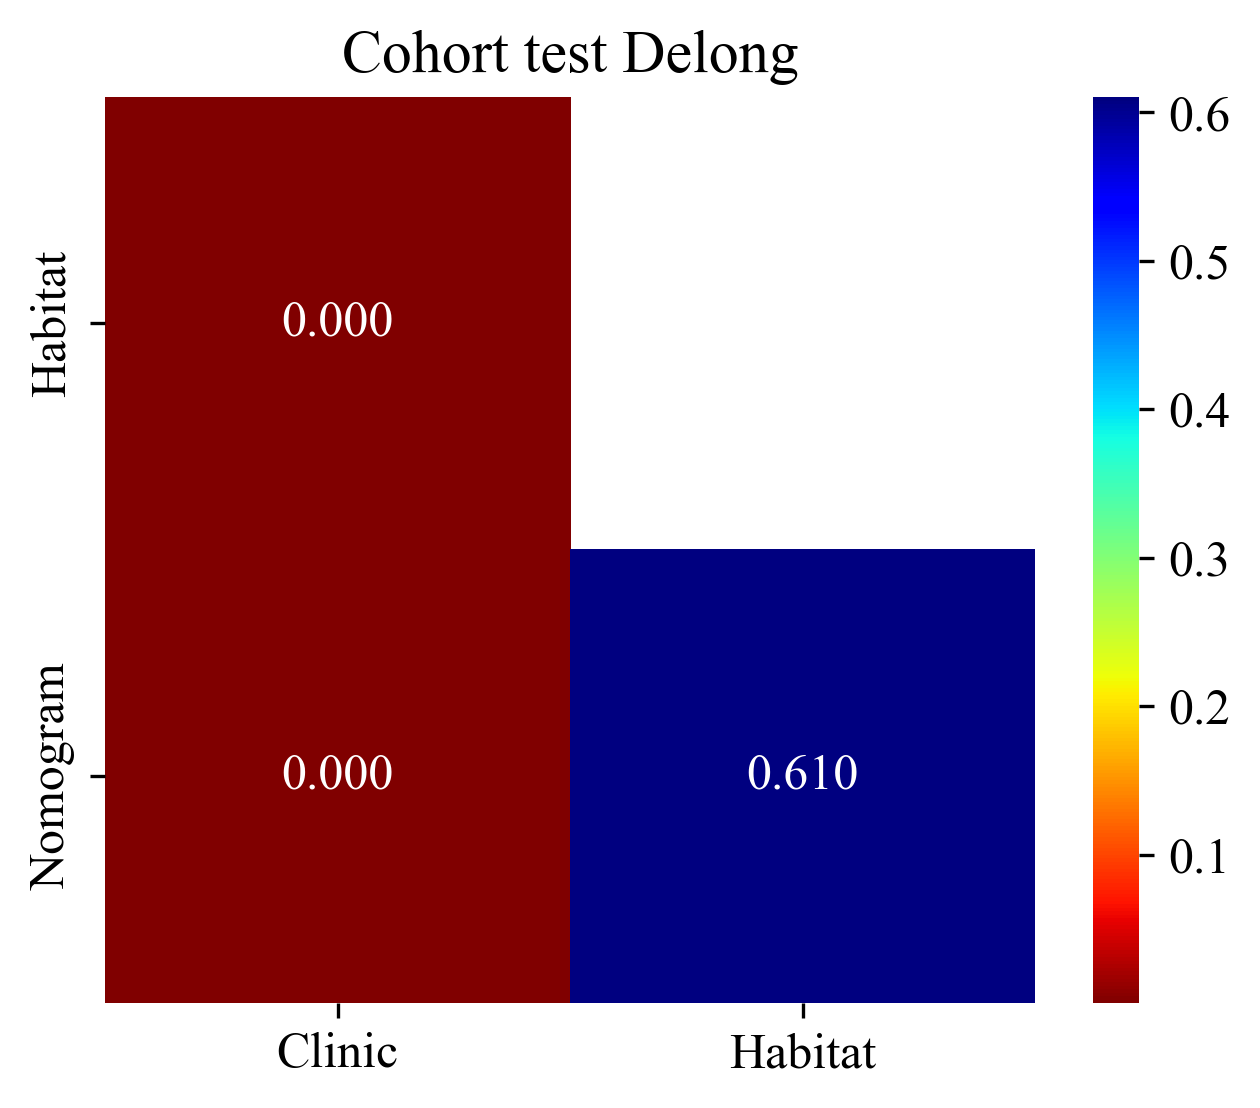

In [15]:
# =====================================================================# WARNING: LEGACY v2 CODE -- DO NOT USE FOR v4 NUMBERS# =====================================================================# This cell uses onekey_algo.custom.components.delong.delong_roc_test,# which is the v2 DeLong implementation (onekey_algo platform). The v4# manuscript reports p-values from the Sun & Xu (2014) analytic DeLong# implementation in Cell 20 of this notebook -- not from this cell.## v2 numbers (this cell, onekey_algo DeLong):#     Habitat vs. Clinic      p = 0.137#     Nomogram vs. Clinic     p = 0.064#     Habitat vs. Nomogram    p = 0.917## v4 numbers (Cell 20/21, Sun & Xu 2014 analytic DeLong):#     Habitat vs. Clinic      p < 0.0001  (Z = +5.89)#     Nomogram vs. Clinic     p < 0.0001  (Z = +5.68)#     Habitat vs. Nomogram    p = 0.877    (Z = -0.155)## This cell is RETAINED FOR TRANSPARENCY / COMPARISON ONLY. The# reviewer should use the Cell 20/21 Sun & Xu analytic results to# verify the manuscript's reported p-values.# =====================================================================from onekey_algo.custom.components.delong import delong_roc_testfrom onekey_algo.custom.components.comp1 import draw_matrixdelong = []delong_columns = []this_delong = []plt.figure(figsize=(5, 4))cm = np.zeros((len(model_names), len(model_names)))for i, mni in enumerate(model_names):    for j, mnj in enumerate(model_names):        if i <= j:            cm[i][j] = np.nan        else:            cm[i][j] = delong_roc_test(ALL_results[task], ALL_results[mni], ALL_results[mnj])[0][0]cm = pd.DataFrame(cm[1:, :-1], index=model_names[1:], columns=model_names[:-1])draw_matrix(cm, annot=True, cmap='jet_r', cbar=True)plt.title(f'Cohort {subset} Delong')plt.savefig(f'img/delong_each_cohort_{subset}.svg', bbox_inches = 'tight')plt.show()

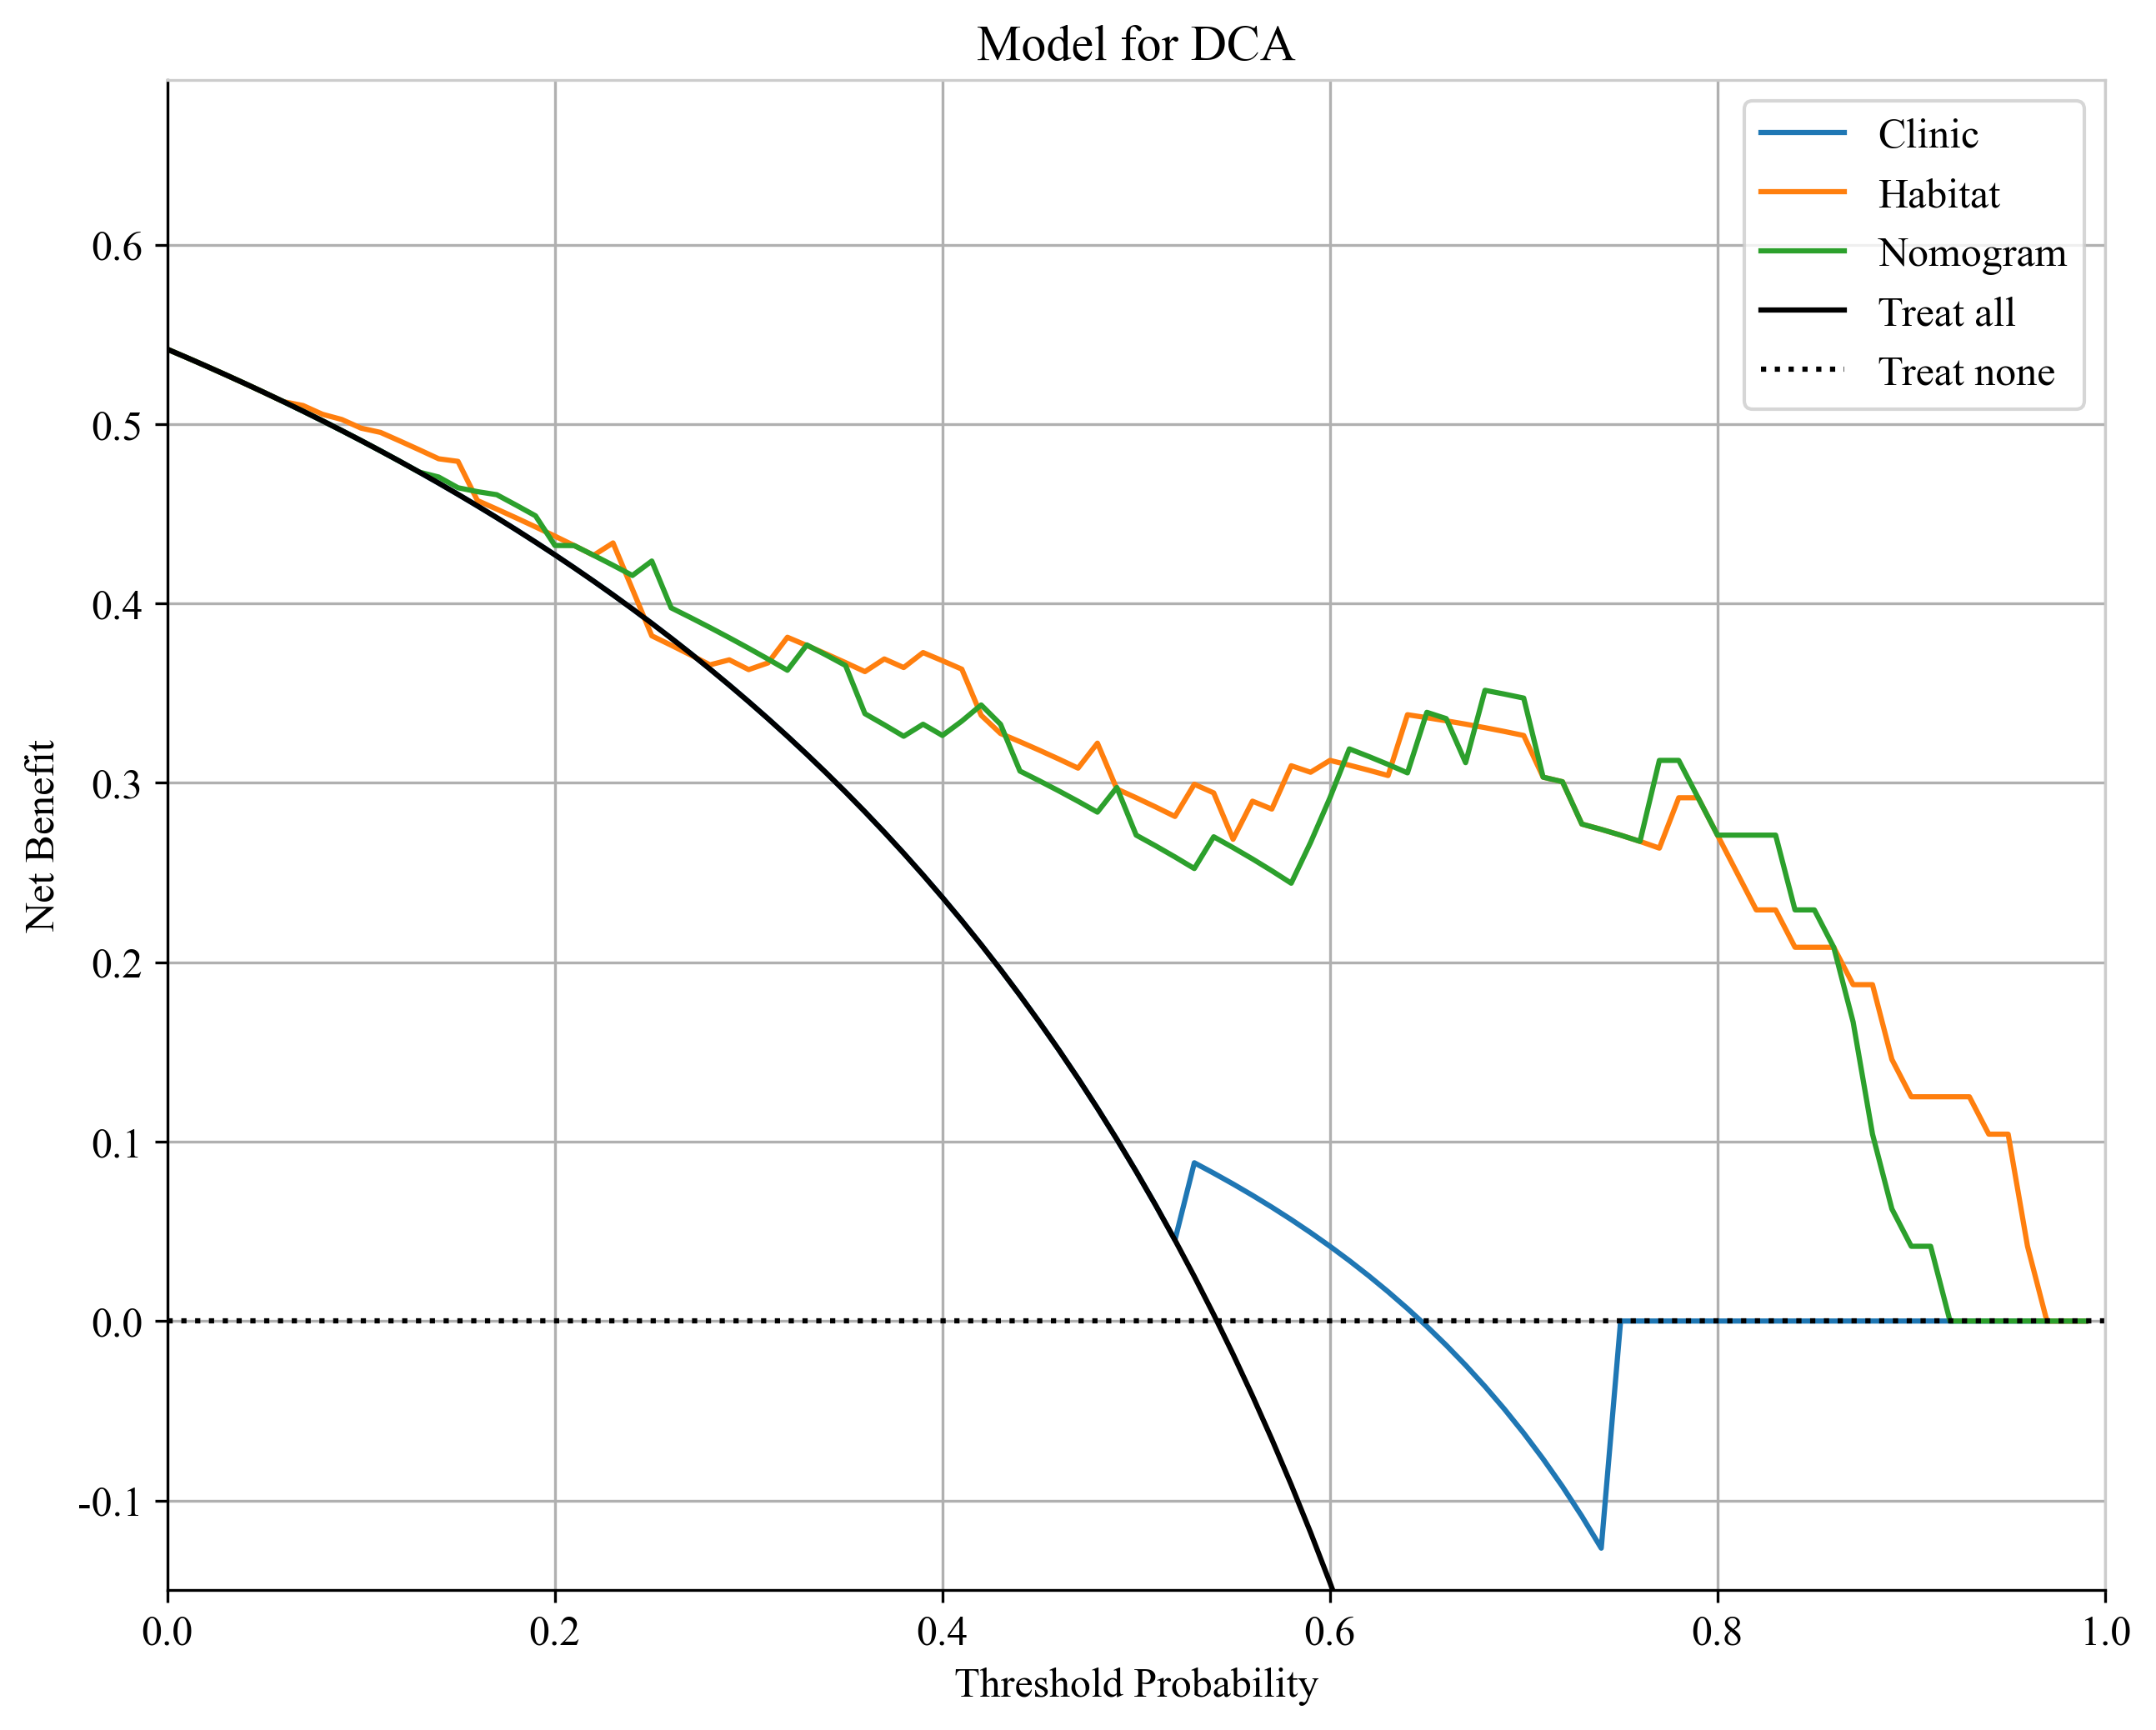

In [16]:
from onekey_algo.custom.components.comp1 import plot_DCA
plot_DCA([ALL_results[mn] for mn in model_names], ALL_results[task], title=f'Model for DCA', labels=model_names)
plt.savefig(f'img/{subset}_dca.svg')

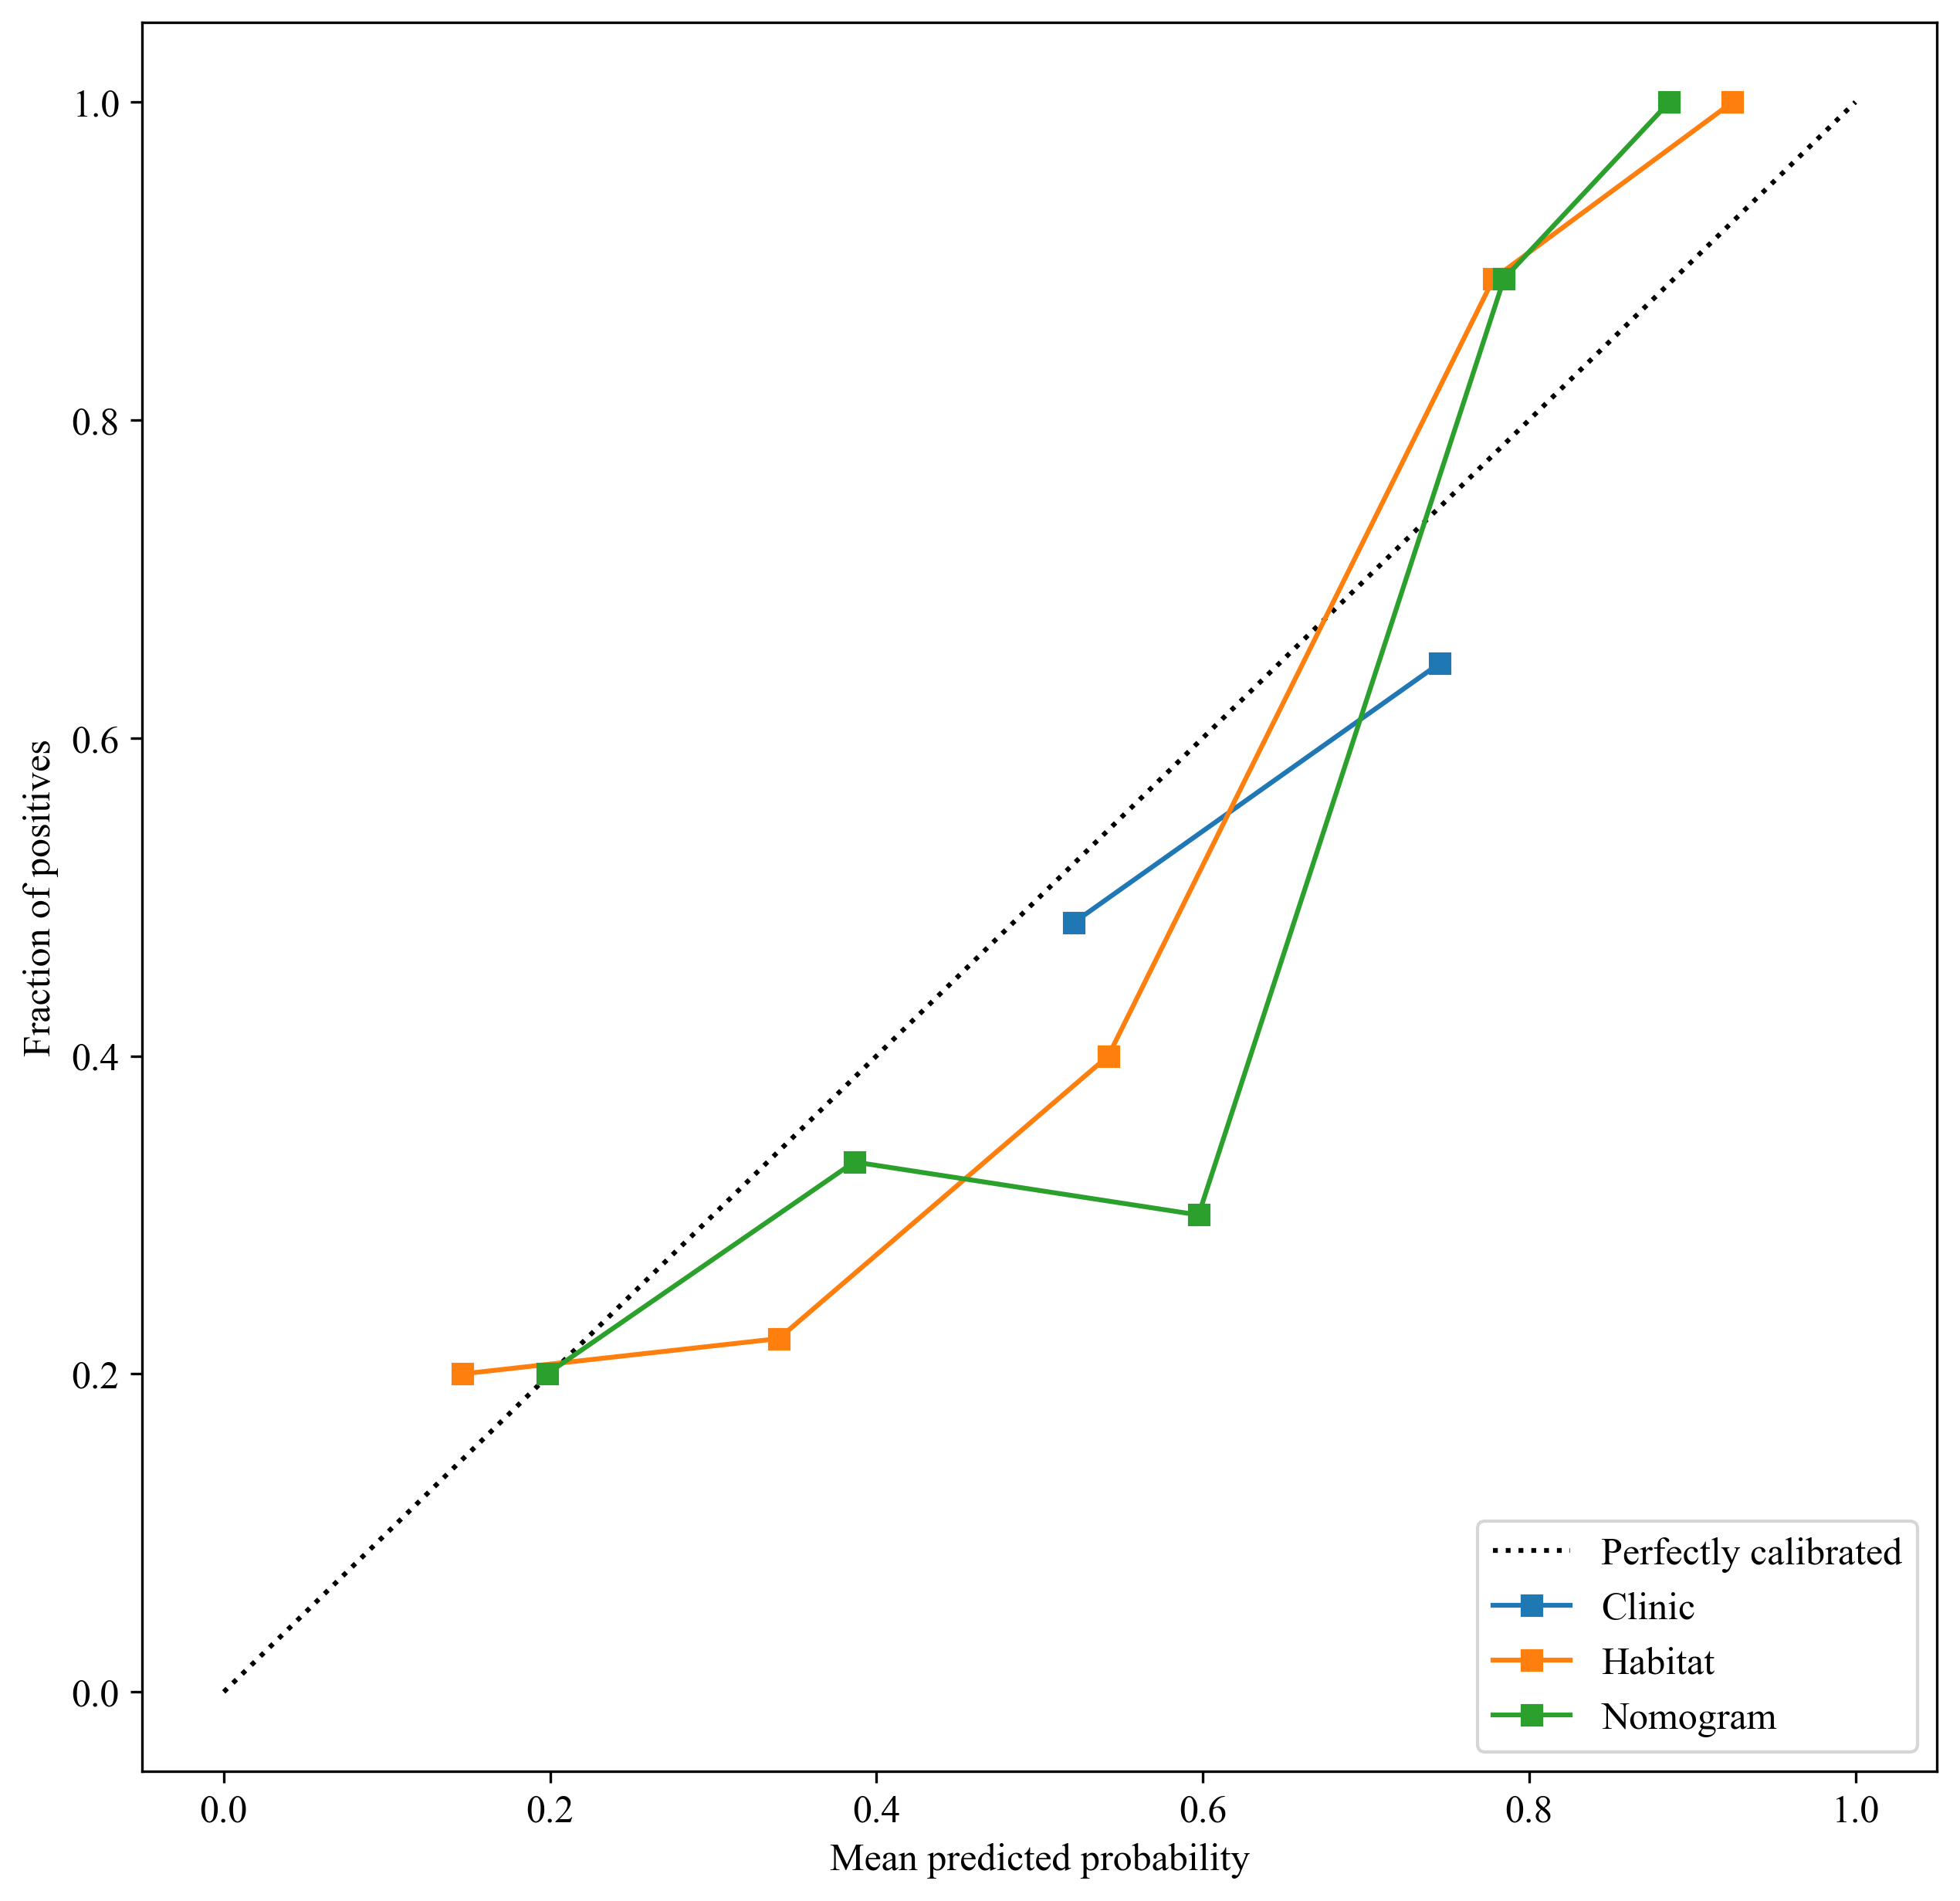

In [17]:
from onekey_algo.custom.components.comp1 import draw_calibration
draw_calibration(pred_scores=pred_train, n_bins=5, y_test=gt, model_names=model_names)
plt.savefig(f'img/{subset}_cali.svg')

In [18]:
from onekey_algo.custom.components import stats

hosmer.append([stats.hosmer_lemeshow_test(y_true, y_pred, bins=5) 
              for fn, y_true, y_pred in zip(model_names, gt, pred_train)])
pd.DataFrame(hosmer, columns=model_names)

,Clinic,Habitat,Nomogram
0,1.000,0.612,0.33
1,0.876,0.383,0.13
